In [22]:
from pathlib import Path
import torch 
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
from matplotlib.colors import ListedColormap
from cmcrameri import cm

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

from tqdm.auto import tqdm
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

from transformers import AutoTokenizer, AutoModel

In [16]:
data = pd.read_csv("../Data_Preparation/processed/m2or_pairs_model.csv")
data

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


# Protein Embeddings

In [17]:
species_to_taxid = {
    'homo sapiens': '9606',
    'mus musculus': '10090',
    'bos taurus': '9913',
    'ovis aries': '9940',
    'canis lupus familiaris': '9615',
    'vulpes vulpes': '9627',
    'puma concolor': '9696',
    'pan paniscus': '9597',
    'pan troglodytes': '9598',
    'pongo abelii': '9601',
    'rattus norvegicus': '10116',
    'dipodomys ordii': '10020',
    'macaca mulatta': '9544',
    'ursus maritimus': '29073',
    'camelus ferus': '419612',
    'equus caballus': '9796'
}

In [18]:
def create_protein_fasta(proteins_df, output_fasta="m2or_unique_1399_proteins.fasta"):

    unique_df = proteins_df.drop_duplicates(subset='Sequence', keep='first')
    
    print(f"Total rows: {len(proteins_df)}")
    print(f"Unique proteins: {len(unique_df)}")
    
    records = []
    
    for _, row in unique_df.iterrows():
        seq_id   = row['seq_id'].strip()
        uniprot  = row['UniProt ID'].strip()
        species  = row['Species'].strip().lower()
        sequence = row['Sequence'].strip()
        
        taxid = species_to_taxid.get(species, 'unknown')
        
        # Header: >seq_id|taxid|UniProt|Species
        header = f">{seq_id}|{taxid}|{uniprot}|{species.replace(' ', '_')}"
        
        record = SeqRecord(
            Seq(sequence),
            id=header[1:],         
            description=""
        )
        records.append(record)
    
    SeqIO.write(records, output_fasta, "fasta")
    print(f"FASTA written: {output_fasta}  ({len(records)} entries)")
    print("Example header:", records[0].id)
    
    return output_fasta

In [19]:
fasta_file = create_protein_fasta(data)

Total rows: 52175
Unique proteins: 1399
FASTA written: m2or_unique_1399_proteins.fasta  (1399 entries)
Example header: SEQ0000|9606|Q8NGN2|homo_sapiens


In [20]:
def compute_esmc_embeddings(fasta_path, output_dir="proteins/esmc_300m_embeddings"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = ESMC.from_pretrained("esmc_300m").to(device).eval()
    
    out_dir = Path(output_dir)
    out_dir.mkdir(exist_ok=True, parents=True)
    
    saved_count = 0
    
    for rec in tqdm(SeqIO.parse(fasta_path, "fasta"), desc="Embedding proteins"):
        header = rec.id                      # e.g. SEQ0000|9606|Q8NGN2|homo_sapiens
        seq    = str(rec.seq)
        
        # Parse header
        try:
            seq_id, taxid, uniprot, species = header.split("|")
            filename = f"{seq_id}.{taxid}.{uniprot}.npy"
        except:
            print(f"Skipping malformed header: {header}")
            continue
        
        protein = ESMProtein(sequence=seq)
        tok = model.encode(protein).to(device)
        
        with torch.no_grad():
            out = model.logits(tok, LogitsConfig(sequence=True, return_embeddings=True))
            emb = out.embeddings.squeeze(0).cpu().numpy()  # [L, 960]
        
        save_path = out_dir / filename
        np.save(save_path, emb)
        saved_count += 1
        
        if saved_count % 100 == 0:
            print(f"Saved {saved_count}: {filename}  shape {emb.shape}")
    
    print(f"Finished. Saved {saved_count} embeddings to {out_dir}")

In [7]:
compute_esmc_embeddings(fasta_file, output_dir="proteins/esmc_300m_embeddings")

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 83886.08it/s]
Embedding proteins: 100it [00:20,  5.12it/s]

Saved 100: SEQ0099.9606.Q8TCB6.npy  shape (320, 960)


Embedding proteins: 201it [00:40,  5.19it/s]

Saved 200: SEQ0199.9606.Q8NH18.npy  shape (314, 960)


Embedding proteins: 301it [01:00,  5.21it/s]

...

Saved 1200: SEQ1199.9606.Q6IEY1.npy  shape (314, 960)


Embedding proteins: 1300it [04:32,  4.71it/s]

Saved 1300: SEQ1302.9606.Q8NH01.npy  shape (318, 960)


Embedding proteins: 1399it [04:53,  4.76it/s]

Finished. Saved 1399 embeddings to proteins/esmc_300m_embeddings


In [8]:
emb_dir = Path("proteins/esmc_300m_embeddings")
assert emb_dir.exists(), f"Folder not found: {emb_dir}"

rows = []
X = []

npy_files = sorted(emb_dir.glob("*.npy"))
print("Found", len(npy_files), "npy files")

for fp in sorted(emb_dir.glob("*.npy")):
    seq_id, tax_id, uniprot_id = fp.stem.split(".")
    emb = np.load(fp, mmap_mode="r")     # (L+2, 960)
    emb = emb[1:-1]                      # (L, 960) remove BOS/EOS
    vec = emb.mean(axis=0)               # (960,)

    rows.append({"file": fp.name, "seq_id": seq_id, "tax_id": tax_id, "uniprot_id": uniprot_id, "L": emb.shape[0]})
    X.append(vec)

df = pd.DataFrame(rows)
X = np.vstack(X)
print(X.shape, df["tax_id"].nunique())

print("Loaded:", X.shape, " (n_proteins, emb_dim)")
print(df["tax_id"].value_counts().head(16))
#df.head()

Found 1399 npy files
(1399, 960) 16
Loaded: (1399, 960)  (n_proteins, emb_dim)
tax_id
9606      1202
10090      167
9913         9
9598         6
9601         3
9597         2
9940         1
9615         1
9696         1
9627         1
10116        1
10020        1
9544         1
29073        1
419612       1
9796         1
Name: count, dtype: int64


In [12]:
import umap

reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.6,
    metric="cosine",
    random_state=42,
)
Z = reducer.fit_transform(X)   # (n, 2)
Z.shape

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(1399, 2)

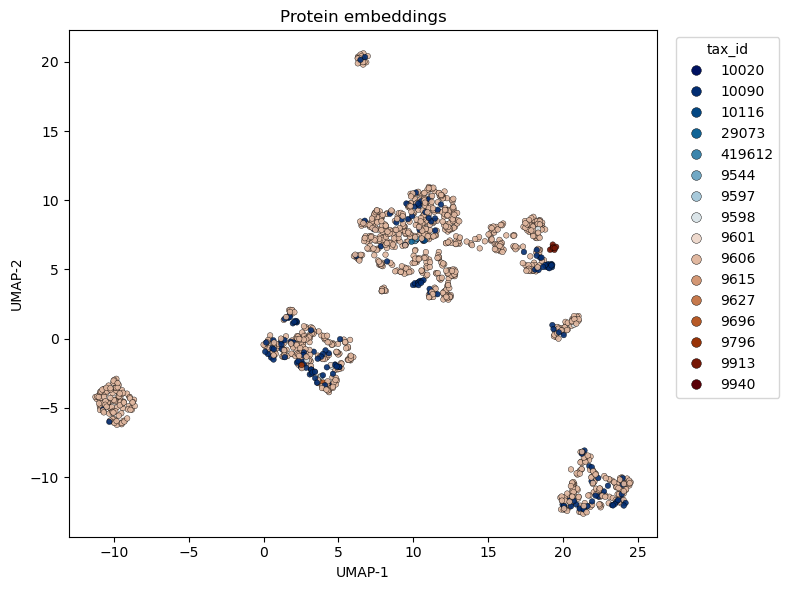

In [ ]:
tax_ids = df["tax_id"].astype(str).values
uniq = sorted(df["tax_id"].astype(str).unique())
tax_to_int = {t:i for i,t in enumerate(uniq)}
c_idx = np.array([tax_to_int[t] for t in tax_ids])

# Make a 16-color discrete version of batlow
cmap16 = ListedColormap(cm.vik(np.linspace(0, 1, 16)), name="vik_16")
cmap = cmap16
norm = plt.Normalize(vmin=0, vmax=len(uniq)-1)

plt.figure(figsize=(8, 6))
plt.scatter(
    Z[:, 0], Z[:, 1],
    c=c_idx,
    cmap=cmap,
    norm=norm,
    s=16,
    alpha=0.9,
    edgecolors="black",
    linewidth=0.3
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("Protein embeddings")

handles = []
for t in uniq:
    i = tax_to_int[t]
    handles.append(
        plt.Line2D(
            [], [], marker="o", linestyle="",
            markersize=7,
            markerfacecolor=cmap16(i),
            markeredgecolor="black",
            markeredgewidth=0.3,
            label=t
        )
    )

plt.legend(handles=handles, title="tax_id",
           bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

# Molecule Embeddings

In [23]:
data["SMILES"].nunique()

754

In [24]:
molformer_tokenizer = AutoTokenizer.from_pretrained("ibm-research/MoLFormer-XL-both-10pct", trust_remote_code=True)
molformer_model = AutoModel.from_pretrained("ibm-research/MoLFormer-XL-both-10pct", trust_remote_code=True).eval().cuda()

In [25]:
unique_smiles = data["SMILES"].dropna().unique().tolist()

lengths = []
for smi in tqdm(unique_smiles):
    ids = molformer_tokenizer(smi, add_special_tokens=True)["input_ids"]
    lengths.append(len(ids))

lengths = np.array(lengths)
print("n_smiles:", len(lengths))
print("min/median/mean/95%/99%/max:",
      lengths.min(),
      int(np.median(lengths)),
      lengths.mean(),
      int(np.percentile(lengths, 95)),
      int(np.percentile(lengths, 99)),
      lengths.max())

100%|██████████| 754/754 [00:00<00:00, 31414.26it/s]

n_smiles: 754
min/median/mean/95%/99%/max: 4 20 20.76923076923077 37 45 141


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
molformer_model = molformer_model.to(device)

def get_molformer_embedding(smi, max_length=256):
    inputs = molformer_tokenizer(
        smi,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = molformer_model(**inputs)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        emb = outputs.pooler_output[0]          # (hidden_dim,)
    else:
        emb = outputs.last_hidden_state[0, 0]   # CLS token (hidden_dim,)
    return emb.detach().cpu()

unique_smiles = data["SMILES"].dropna().unique().tolist()
smiles_embeddings = {}

max_length = 256
for smi in tqdm(unique_smiles):
    smiles_embeddings[smi] = get_molformer_embedding(smi, max_length=max_length)

output_path = "molecules/molformer_smiles_embeddings.pt"
torch.save(smiles_embeddings, output_path)

100%|██████████| 754/754 [00:19<00:00, 38.91it/s]


/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


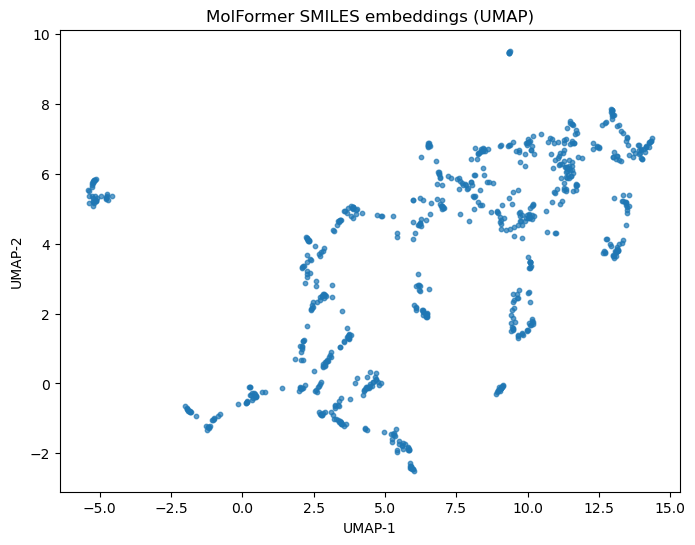

In [37]:
import umap

smiles_embeddings = torch.load("molecules/molformer_smiles_embeddings.pt")

smiles = list(smiles_embeddings.keys())
emb_matrix = torch.stack([smiles_embeddings[smi] for smi in smiles]).numpy()

reducer = umap.UMAP(n_neighbors=10, 
                    min_dist=0.1, 
                    metric='cosine', 
                    random_state=42)

embedding_2d = reducer.fit_transform(emb_matrix)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, alpha=0.7)
plt.title("MolFormer SMILES embeddings (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()